In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.43 s (started: 2026-07-04 09:40:44 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name="kang_15K_pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

scarf.fetch_dataset(
    dataset_name="kang_14K_ifnb-pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

time: 27.6 s (started: 2026-07-04 09:40:45 +02:00)


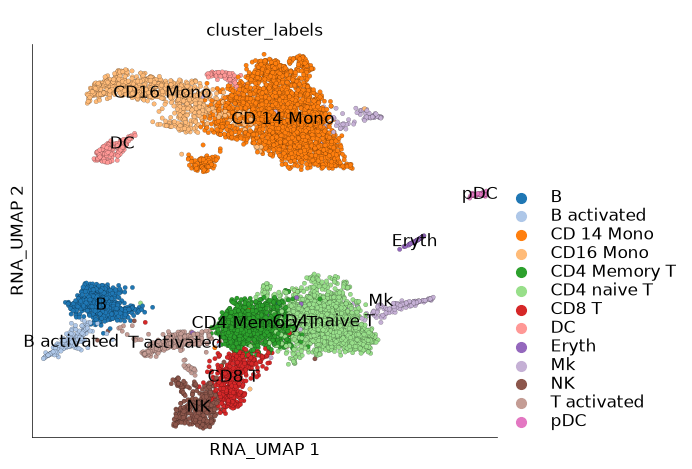

time: 700 ms (started: 2026-07-04 09:41:12 +02:00)


In [3]:
# Control/untreated PBMC data
ds_ctrl = scarf.DataStore("scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr", nthreads=4)

ds_ctrl.plot_layout(layout_key="RNA_UMAP", color_by="cluster_labels")

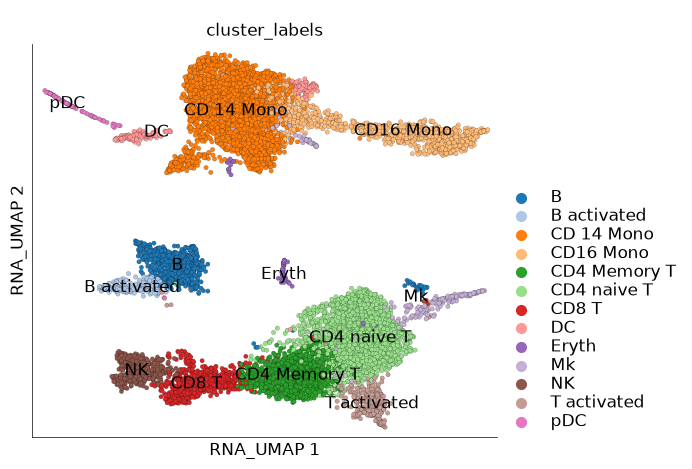

time: 456 ms (started: 2026-07-04 09:41:13 +02:00)


In [4]:
# Interferon beta stimulated PBMC data
ds_stim = scarf.DataStore(
    "scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr", nthreads=4
)

ds_stim.plot_layout(layout_key="RNA_UMAP", color_by="cluster_labels")

In [5]:
# CORAL algorithm can be very slow with large number of features (> 5000).
# Hence here it is recommended for only scRNA-Seq datasets.

ds_ctrl.run_mapping(
    target_assay=ds_stim.RNA,
    target_name="stim",
    target_feat_key="hvgs_ctrl",
    save_k=5,
    run_coral=True,
)

0 features missing in target data



Loaded existing ANN stream from RNA/normed__I__hvgs/reduction__pca__25__I/ann__l2__50__50__48__4466



Calculating fractional power of covariance matrices. This might take a while... 



Fractional power calculation complete



time: 31 s (started: 2026-07-04 09:41:13 +02:00)


Target cluster CD 14 Mono


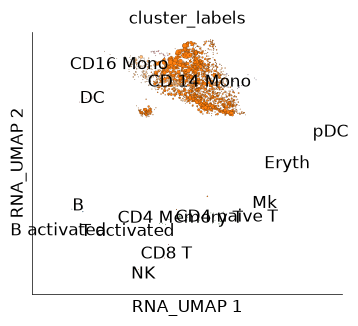

Target cluster NK


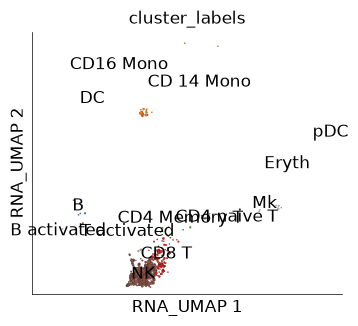

time: 752 ms (started: 2026-07-04 09:41:44 +02:00)


In [6]:
# Here we will generate plots for IFB-B stimulated cells from NK  and CD14 monocyte clusters.

for g, ms in ds_ctrl.get_mapping_score(
    target_name="stim",
    target_groups=ds_stim.cells.fetch("cluster_labels"),
    log_transform=True,
):
    if g in ["NK", "CD 14 Mono"]:
        print(f"Target cluster {g}")
        ds_ctrl.plot_layout(
            layout_key="RNA_UMAP",
            color_by="cluster_labels",
            size_vals=ms * 10,
            height=4,
            width=4,
            legend_onside=False,
        )

In [7]:
transferred_labels = ds_ctrl.get_target_classes(
    target_name="stim", reference_class_group="cluster_labels"
)

transferred_labels

0                  NK
1                 pDC
2         CD4 naive T
3                   B
4         CD4 naive T
             ...     
10106      CD 14 Mono
10107    CD4 Memory T
10108               B
10109      CD 14 Mono
10110     CD4 naive T
Length: 10111, dtype: object

time: 127 ms (started: 2026-07-04 09:41:44 +02:00)


In [8]:
ds_stim.cells.insert("transferred_labels", transferred_labels.values, overwrite=True)

time: 62.2 ms (started: 2026-07-04 09:41:44 +02:00)


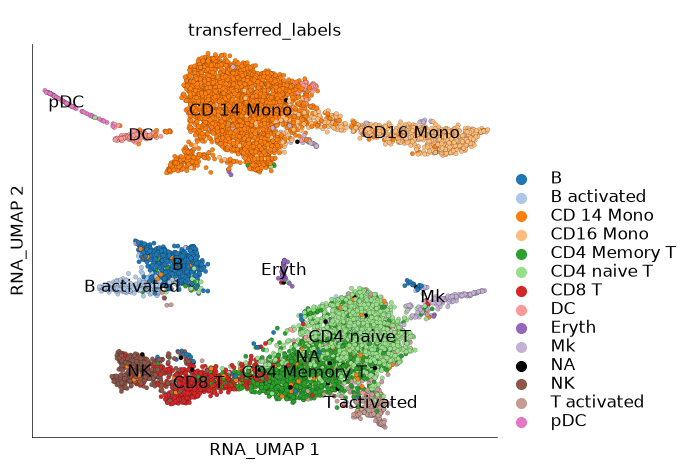

time: 485 ms (started: 2026-07-04 09:41:45 +02:00)


In [9]:
ds_stim.plot_layout(layout_key="RNA_UMAP", color_by="transferred_labels")

In [10]:
import pandas as pd

df = pd.crosstab(
    ds_stim.cells.fetch("cluster_labels"), ds_stim.cells.fetch("transferred_labels")
)
df

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,649,26,19,0,15,20,0,1,0,4,3,1,6,2
B activated,24,171,3,0,1,2,1,0,0,0,2,1,0,0
CD 14 Mono,0,0,2381,132,3,1,0,7,0,6,2,0,0,0
CD16 Mono,1,0,230,717,0,0,0,1,0,7,0,0,0,0
CD4 Memory T,5,0,45,1,923,217,72,0,1,5,18,0,10,0
CD4 naive T,14,4,36,0,356,1896,16,2,1,16,19,2,28,0
CD8 T,10,0,23,0,59,14,461,0,0,2,5,76,5,0
DC,0,0,73,4,0,0,0,137,0,0,0,0,0,0
Eryth,0,0,11,0,1,23,1,0,46,0,1,0,0,0


time: 141 ms (started: 2026-07-04 09:41:45 +02:00)


In [11]:
(100 * df / df.sum(axis=0)).round(1)

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,91.8,12.9,0.7,0.0,1.1,0.9,0.0,0.6,0.0,2.1,5.9,0.2,2.2,2.9
B activated,3.4,84.7,0.1,0.0,0.1,0.1,0.2,0.0,0.0,0.0,3.9,0.2,0.0,0.0
CD 14 Mono,0.0,0.0,82.6,15.4,0.2,0.0,0.0,4.5,0.0,3.1,3.9,0.0,0.0,0.0
CD16 Mono,0.1,0.0,8.0,83.9,0.0,0.0,0.0,0.6,0.0,3.6,0.0,0.0,0.0,0.0
CD4 Memory T,0.7,0.0,1.6,0.1,65.4,9.8,12.2,0.0,2.0,2.6,35.3,0.0,3.7,0.0
CD4 naive T,2.0,2.0,1.2,0.0,25.2,85.3,2.7,1.3,2.0,8.3,37.3,0.4,10.5,0.0
CD8 T,1.4,0.0,0.8,0.0,4.2,0.6,78.1,0.0,0.0,1.0,9.8,16.6,1.9,0.0
DC,0.0,0.0,2.5,0.5,0.0,0.0,0.0,89.0,0.0,0.0,0.0,0.0,0.0,0.0
Eryth,0.0,0.0,0.4,0.0,0.1,1.0,0.2,0.0,92.0,0.0,2.0,0.0,0.0,0.0


time: 14.4 ms (started: 2026-07-04 09:41:45 +02:00)


In [12]:
ds_ctrl.run_unified_umap(
    target_names=["stim"],
    ini_embed_with="RNA_UMAP",
    target_weight=1,
    use_k=5,
    n_epochs=100,
)

Training UMAP:   0%|                                                                                          …

time: 13.1 s (started: 2026-07-04 09:41:45 +02:00)


/home/parashar/scarf/scarf/metadata.py:344: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


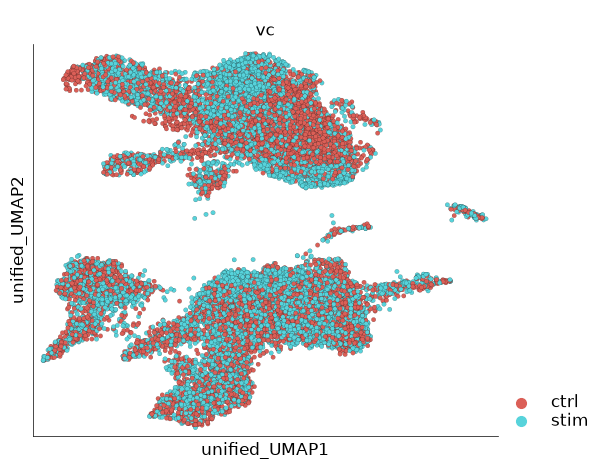

time: 209 ms (started: 2026-07-04 09:41:58 +02:00)


In [13]:
ds_ctrl.plot_unified_layout(
    layout_key="unified_UMAP", show_target_only=False, ref_name="ctrl"
)

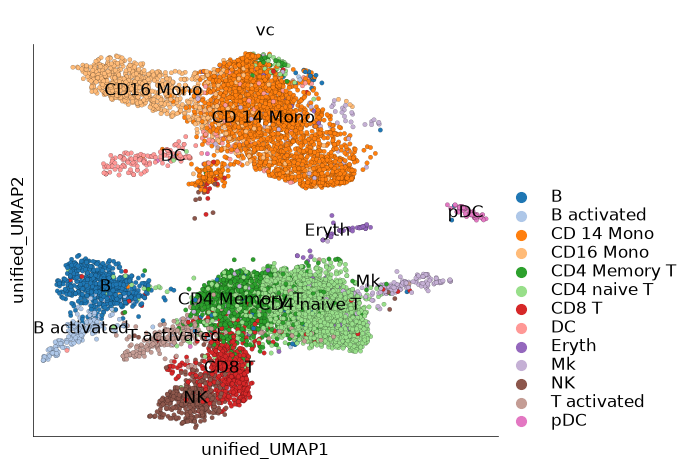

time: 258 ms (started: 2026-07-04 09:41:59 +02:00)


In [14]:
ds_ctrl.plot_unified_layout(
    layout_key="unified_UMAP",
    show_target_only=True,
    legend_ondata=True,
    target_groups=ds_stim.cells.fetch("cluster_labels"),
)

Number of vertices: 18598


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


Maximum iterations: 500


...

Iteration 400: error is 4.64599 (50 iterations in 0.291826 seconds)


Iteration 450: error is 4.61348 (50 iterations in 0.310429 seconds)


Iteration 499: error is 4.58653 (50 iterations in 0.329019 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.564756 sec [23.681%] |  Repulsive forces: 1.8201 sec [76.319%]


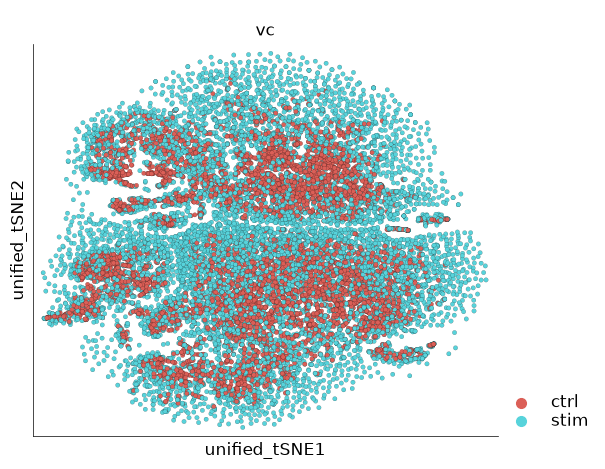

time: 3.25 s (started: 2026-07-04 09:41:59 +02:00)


In [15]:
ds_ctrl.run_unified_tsne(
    target_names=["stim"],
    ini_embed_with="RNA_UMAP",
    target_weight=1,
    use_k=5,
    max_iter=500,
)

ds_ctrl.plot_unified_layout(
    layout_key="unified_tSNE", show_target_only=False, ref_name="ctrl"
)